# Projeto G1 — Dashboard Executivo de Análise da Qualidade do Ar no Brasil

Disciplina: Linguagem de Programação — Análise e Visualização de Dados com Python

Aluno: Davi Cavalcante Rodrigues Scarpelli

Professor: Alexandre Neves Louzada

Este projeto tem como objetivo analisar os dados sobre a qualidade do ar em diversos estados do Brasil,
identificando padrões e tendências relevantes.



# 1. Introdução ao problema

## Contextualização

**A qualidade do ar influencia diretamente:**

- Saúde Pública

- Qualidade de vida

- Meio ambiente

- Mobilidade urbana

- Sustentabilidade das cidades

**A partir disso, o projeto deseja responder as seguintes perguntas:**

- Quais cidades apresentam pior qualidade do ar? 

- Existem períodos mais críticos? 

- Quais poluentes são mais frequentes?

- Existe relação entre clima e poluição?

- Há melhora ou piora da qualidade do ar ao longo do tempo?

- Quais regiões apresentam maior concentração de poluentes?

- Quais cidades exigem maior atenção ambiental?



In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 2. Leitura da base de dados

In [192]:
df = pd.read_csv("../dados/simulacao_qualidade_ar_brasil.csv")

df.head()

,ano,mes,data,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade
0,2015,1,2015-01-01,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada
1,2015,1,2015-01-01,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada
2,2015,1,2015-01-01,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada
3,2015,1,2015-01-01,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada
4,2015,1,2015-01-01,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada


# 3. Check-up inicial da base

In [193]:
print("Dimensões da base: ", df.shape)
print("\nTipos de dados: ")
print(df.dtypes)

print("\nValores ausentes: ")
print(df.isnull().sum())

print("\nDuplicidades: ")
print(df.duplicated().sum())

Dimensões da base:  (4440, 15)

Tipos de dados: 
ano                      int64
mes                      int64
data                    object
regiao                  object
uf                      object
cidade                  object
pm25                   float64
pm10                   float64
no2                    float64
co                     float64
o3                     float64
temperatura_media      float64
umidade                float64
indice_qualidade_ar    float64
nivel_qualidade         object
dtype: object

Valores ausentes: 
ano                    0
mes                    0
data                   0
regiao                 0
uf                     0
cidade                 0
pm25                   0
pm10                   0
no2                    0
co                     0
o3                     0
temperatura_media      0
umidade                0
indice_qualidade_ar    0
nivel_qualidade        0
dtype: int64

Duplicidades: 
0


# 4. Preparação dos dados e engenharia de atributos

In [194]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

def definir_estacao(mes):
    if mes in [12, 1, 2]:
        return "Verão"
    elif mes in [3, 4, 5]:
        return "Outono"
    elif mes in [6, 7, 8]:
        return "Inverno"
    else:
        return "Primavera"

df["estacao"] = df["mes"].apply(definir_estacao)

df = df.drop(columns=["data"])

df.head()

,ano,mes,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade,ano_mes,estacao
0,2015,1,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada,2015-01,Verão
1,2015,1,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada,2015-01,Verão
2,2015,1,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada,2015-01,Verão
3,2015,1,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada,2015-01,Verão
4,2015,1,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada,2015-01,Verão


# 5. KPIs principais

- Índice médio de qualidade do ar

- Cidade mais poluída

- Poluente predominante

- Percentual de dias críticos

- Região mais afetada

- Média de PM2.5



In [195]:
qualidade_media = df["indice_qualidade_ar"].mean()

media_poluicao_cidades = df.groupby("cidade")["indice_qualidade_ar"].mean().sort_values(ascending=False)

cidade_mais_poluida = media_poluicao_cidades.idxmax()

media_poluicao = df[["pm25", "pm10", "no2", "co", "o3"]].mean()

percentual_dias_criticos = (df["nivel_qualidade"] == "Ruim").mean() * 100

media_poluicao_regioes = df.groupby("regiao")["indice_qualidade_ar"].mean().sort_values(ascending=False)

regiao_mais_poluida = media_poluicao_regioes.idxmax()

media_pm25 = df["pm25"].mean()

evolucao_anual = df.groupby("ano")["indice_qualidade_ar"].mean()

print(f"Qualidade média do ar: {qualidade_media:.2f}")

print(f"\nCidade com maior poluicao media: {cidade_mais_poluida}")

print("\nMedia de poluicao: ")
for i,j in media_poluicao.items():
    print(f"{i}: {j:.2f}")

print(f"\nPercentual de dias criticos: {percentual_dias_criticos:.2f}%")

print(f"\nRegiao mais afetada pela poluicao: {regiao_mais_poluida}")

print(f"\nMedia de pm25: {media_pm25:.2f}")

print(f"\nEvolução anual: {evolucao_anual}")

Qualidade média do ar: 67.74

Cidade com maior poluicao media: Florianópolis

Media de poluicao: 
pm25: 35.06
pm10: 70.03
no2: 24.86
co: 1.06
o3: 40.13

Percentual de dias criticos: 11.80%

Regiao mais afetada pela poluicao: Sul

Media de pm25: 35.06

Evolução anual: ano
2015    67.763446
2016    67.997297
2017    66.997387
2018    68.517680
2019    68.594369
2020    67.198041
2021    67.740383
2022    66.957207
2023    67.966036
2024    67.690586
Name: indice_qualidade_ar, dtype: float64


# 6. Persistência com SQLAlchemy e SQLite

In [196]:
engine = create_engine("sqlite:///../database/qualidade_ar_brasil.sqlite")

df.to_sql("qualidade_ar", engine, if_exists="replace", index=False)

print("Tabela de qualidade do ar criada no banco SQLite.")

Tabela de qualidade do ar criada no banco SQLite.


# 7. Visualização Estatística com Gráficos

### Gráfico das cidades com maior índice de poluição

A partir desse gráfico, conseguimos medir quais são as cidades com o pior índice de poluição do ar

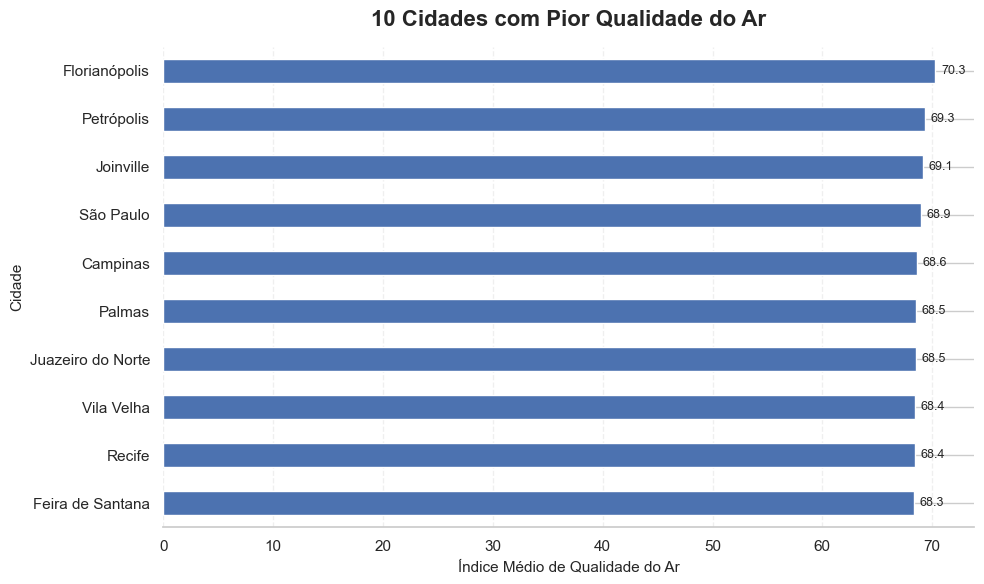

In [197]:
piores_cidades = media_poluicao_cidades.head(10)
plt.figure(figsize=(10, 6))
x = piores_cidades.sort_values().plot(kind="barh")

plt.title("10 Cidades com Pior Qualidade do Ar", fontsize=16, pad=15, fontweight="bold")
plt.xlabel("Índice Médio de Qualidade do Ar", fontsize=11)
plt.ylabel("Cidade", fontsize=11)

x.grid(axis="x", linestyle="--", alpha=0.3)
x.set_axisbelow(True)

x.spines["top"].set_visible(False)
x.spines["right"].set_visible(False)
x.spines["left"].set_visible(False)

for i, valor in enumerate(piores_cidades.sort_values()):
    x.text(valor + 0.5, i, f"{valor:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Gráfico de qualidade média por mês

Esse gráfico compara a média de cada um dos meses de todos os anos da pesquisa. A partir dele, conseguimos ver os piores e melhores meses em relação à poluição do ar

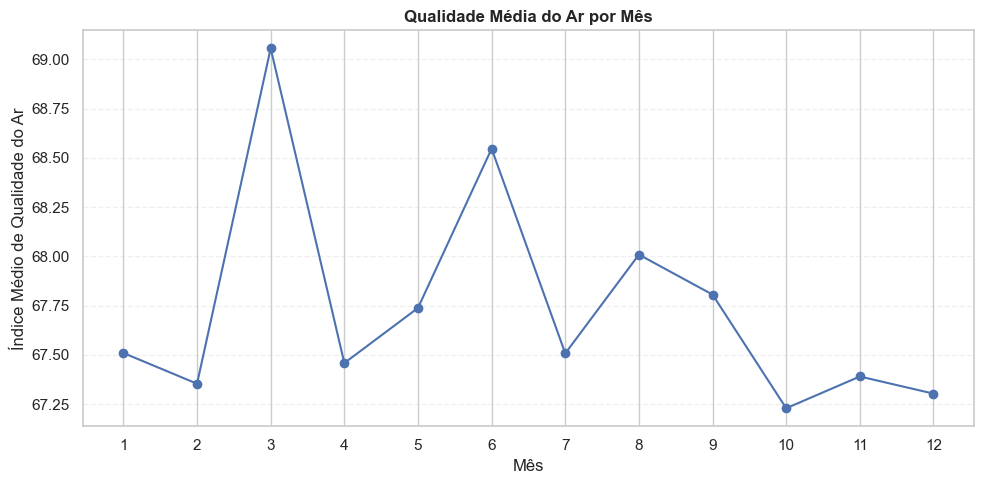

In [198]:
qualidade_por_mes = (
    df.groupby("mes")["indice_qualidade_ar"]
      .mean()
)

plt.figure(figsize=(10, 5))

qualidade_por_mes.plot(kind="line", marker="o")

plt.title("Qualidade Média do Ar por Mês", fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Índice Médio de Qualidade do Ar")

plt.xticks(range(1, 13))
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Gráfico de correlação poluentes, clima e qualidade do ar

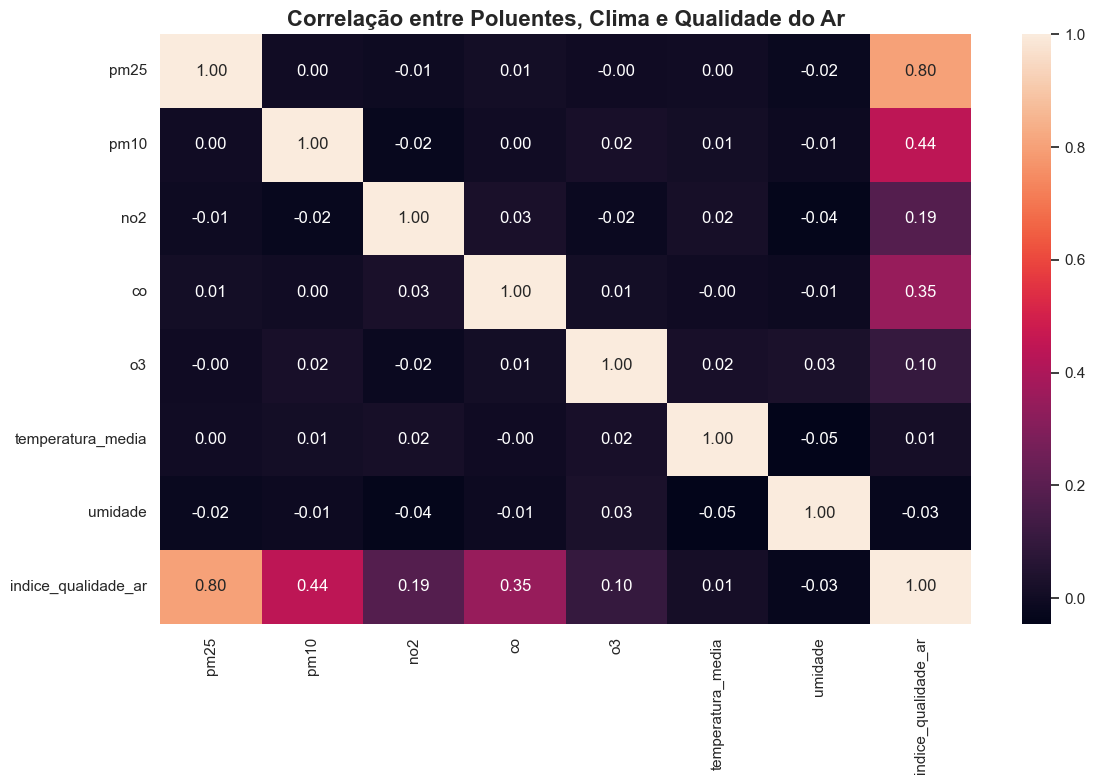

In [199]:
variaveis = [
    "pm25",
    "pm10",
    "no2",
    "co",
    "o3",
    "temperatura_media",
    "umidade",
    "indice_qualidade_ar"
]

correlacao = df[variaveis].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f"
)

plt.title("Correlação entre Poluentes, Clima e Qualidade do Ar", fontweight="bold",fontsize=16)

plt.tight_layout()
plt.show()

A partir dessa análise de correlação, é possível entender que **existe uma grande correlação positiva entre o índice pm25 e o índice de qualidade do ar.**Logo, índices altos de pm25 tendem a significar uma qualidade ruim do ar

Por outro lado, o gráfico de correlação indica que **não existe uma correlação forte entre temperatura ou umidade com o índice de qualidade do ar**

### Gráfico de evolução anual

#### Evolução de acordo com a quantidade de dias críticos

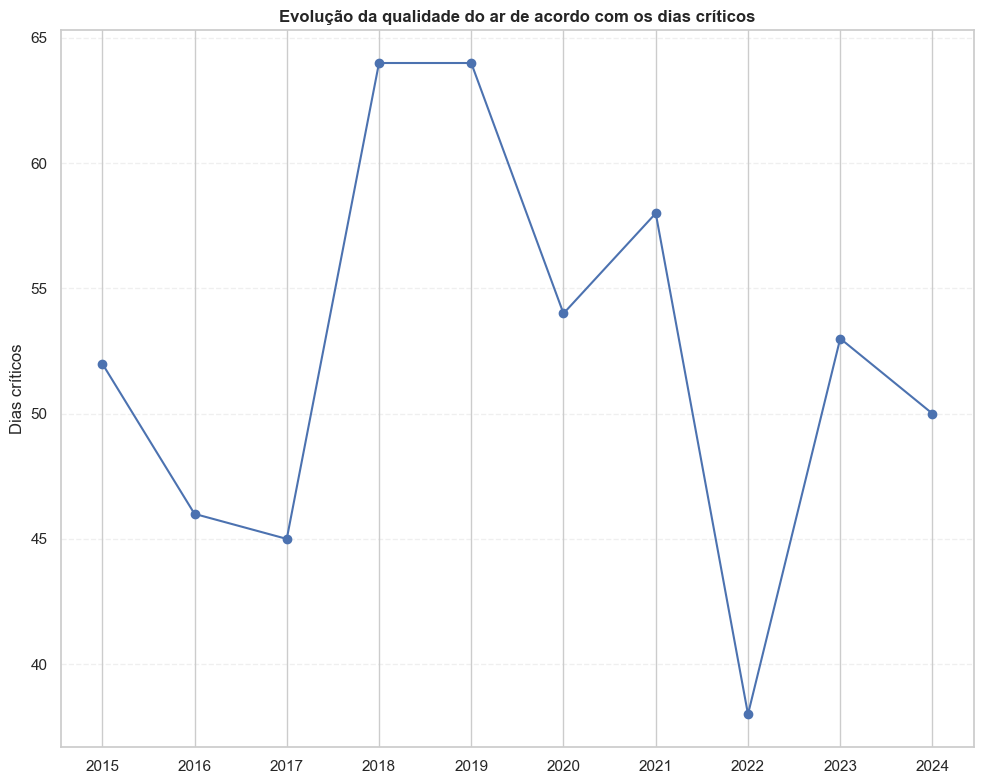

In [200]:
plt.figure(figsize=(10, 8))

ocorrencias_criticas_anuais = (df[df["nivel_qualidade"] == "Ruim"].groupby("ano").size())

ocorrencias_criticas_anuais.plot(kind="line", marker="o")

plt.title("Evolução da qualidade do ar de acordo com os dias críticos", fontweight="bold")
plt.xlabel("")
plt.ylabel("Dias críticos")

plt.xticks(ocorrencias_criticas_anuais.index)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Evolução de acordo com a média do índice de qualidade do ar

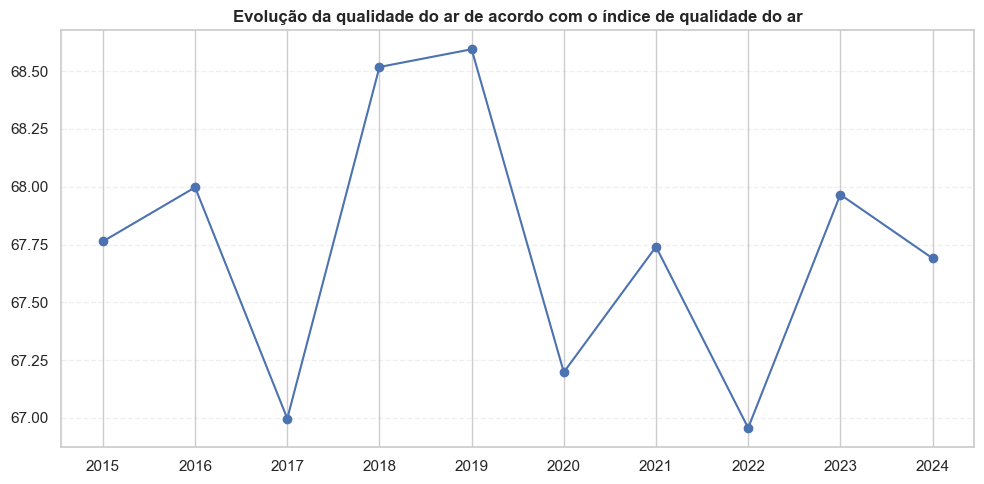

In [201]:
plt.figure(figsize=(10, 5))

evolucao_anual.plot(kind="line", marker="o")

plt.title("Evolução da qualidade do ar de acordo com o índice de qualidade do ar", fontweight="bold")
plt.xlabel("")
plt.ylabel("")

plt.xticks(evolucao_anual.index)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Índice de qualidade do ar por região

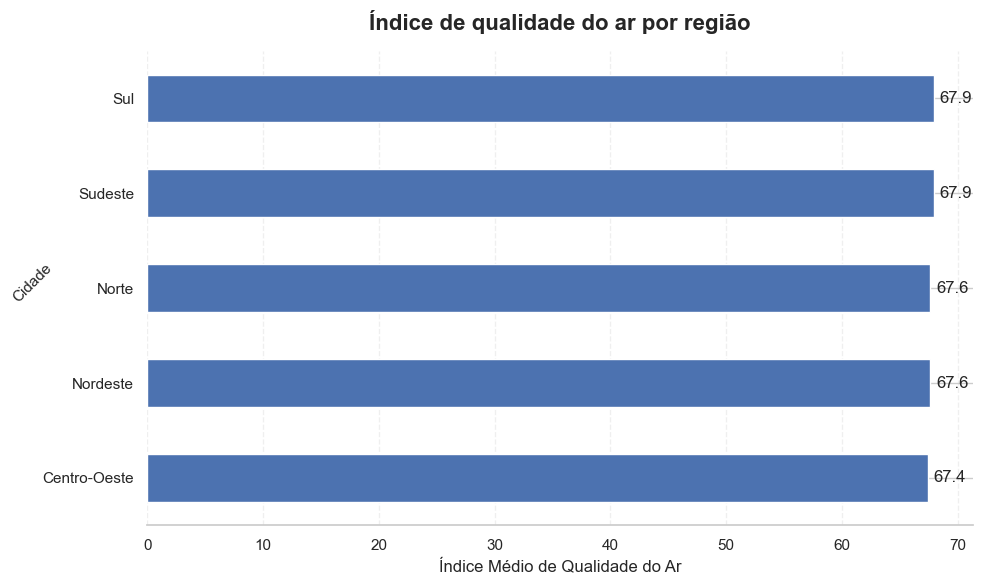

In [202]:
plt.figure(figsize=(10, 6))
x = media_poluicao_regioes.sort_values().plot(kind="barh")

plt.title("Índice de qualidade do ar por região", fontsize=16, pad=15, fontweight="bold")
plt.xlabel("Índice Médio de Qualidade do Ar", fontsize=12)
plt.ylabel("Cidade", fontsize=11, rotation=45)

x.grid(axis="x", linestyle="--", alpha=0.3)
x.set_axisbelow(True)

for i, valor in enumerate(media_poluicao_regioes.sort_values()):
    x.text(valor + 0.5, i, f"{valor:.1f}", va="center", fontsize=12)

x.spines["top"].set_visible(False)
x.spines["right"].set_visible(False)
x.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### Análise das cidades com maiores ocorrências críticas de qualidade do ar

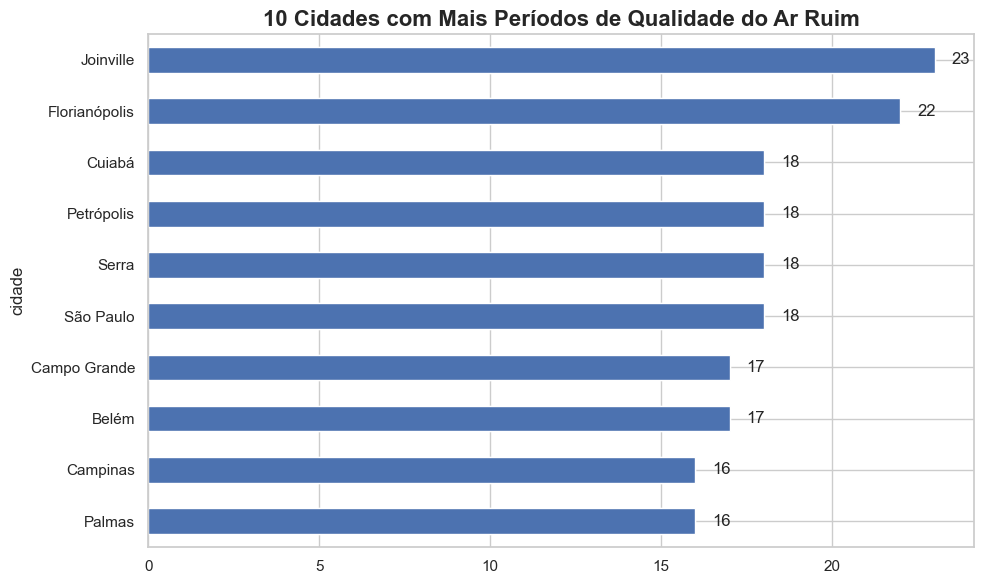

In [182]:
cidades_criticas = (
    df[df["nivel_qualidade"] == "Ruim"]
    .groupby("cidade")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

cidades_criticas.sort_values().plot(kind="barh")

plt.title("10 Cidades com Mais Períodos de Qualidade do Ar Ruim", fontweight="bold", fontsize=16)
plt.xlabel("Quantidade de períodos")
plt.ylabel("Cidade")

x = cidades_criticas.sort_values().plot(kind="barh")

for i, valor in enumerate(cidades_criticas.sort_values()):
    x.text(valor + 0.5, i, f"{valor}", va="center", fontsize=12)

plt.tight_layout()
plt.show()

# 8. Conclusão

A análise mostra como uma base de dados de qualidade do ar pode ser transformada em um produto analítico capaz de gerar informações relevantes para a tomada de decisão.

O projeto permite identificar:

- Quais cidades apresentam maior frequência de períodos críticos;

- Quais regiões apresentam os maiores índices de qualidade do ar;

- Como a qualidade do ar varia ao longo do tempo;

- Quais poluentes apresentam maior presença nos dados analisados;

- Quais relações existem entre os poluentes, a qualidade do ar e as variáveis climáticas.

Essas informações podem auxiliar gestores e órgãos responsáveis pelo monitoramento ambiental a identificar regiões e períodos que exigem maior atenção, além de contribuir para o planejamento de ações de controle e redução da poluição atmosférica.